<a href="https://colab.research.google.com/github/Yash-k10/Machine_vision/blob/main/practical4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving img4.jpg to img4.jpg


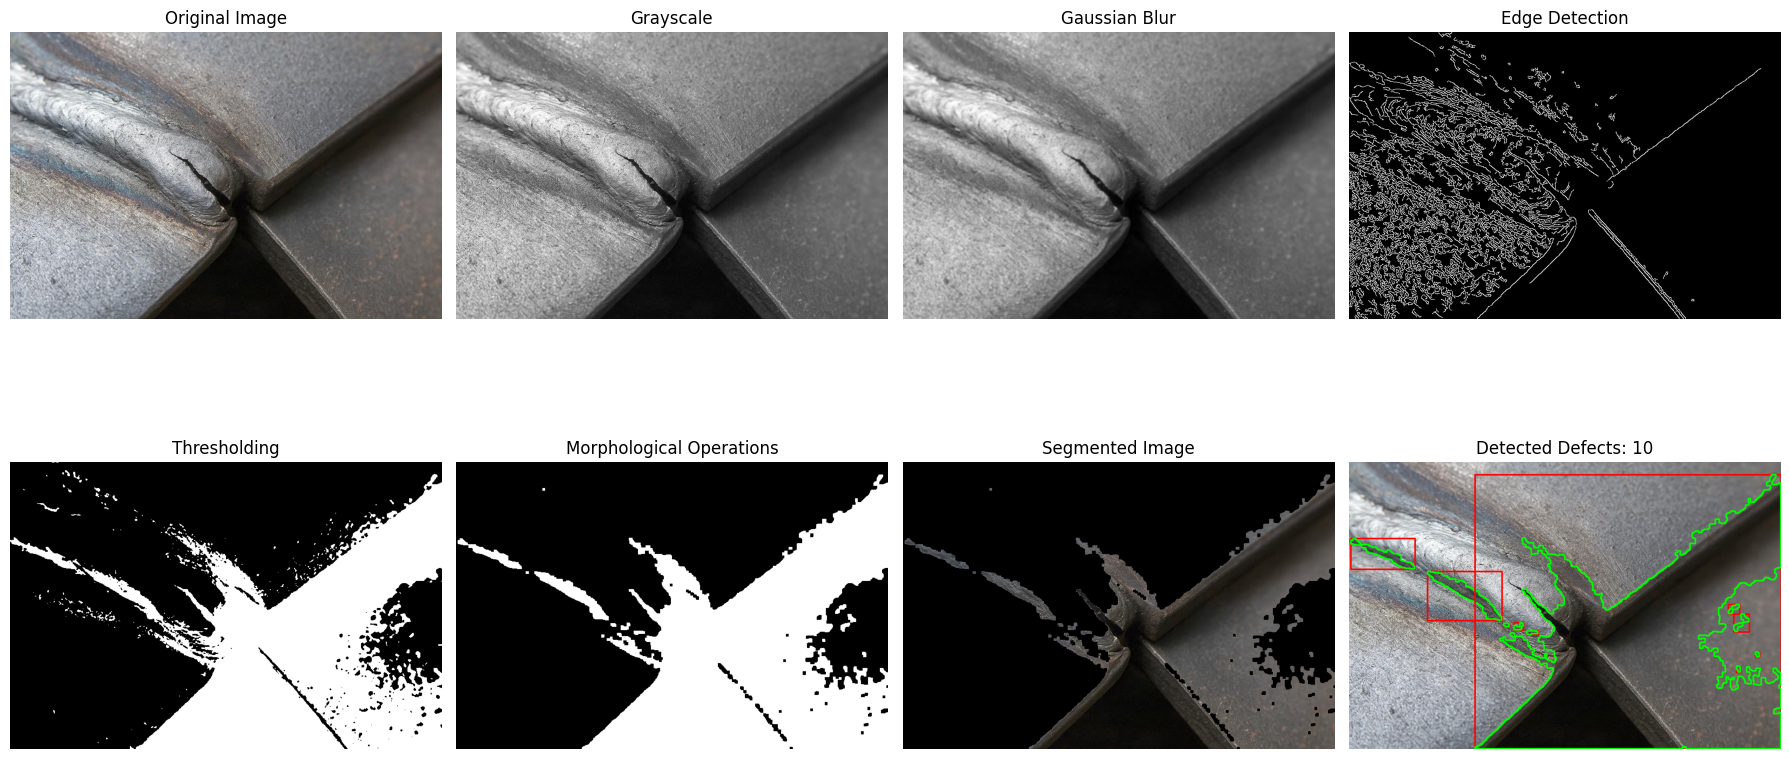

Metal Surface Defect Detection Completed
Total Defects Detected : 10
Techniques Used:
1. Grayscale Conversion
2. Gaussian Blur
3. Canny Edge Detection
4. Otsu Thresholding
5. Morphological Opening
6. Morphological Closing
7. Image Segmentation
8. Contour Extraction
9. Bounding Box Detection


In [1]:
# ================================================================
# Metal Surface Defect Detection using OpenCV
# Techniques Used:
# 1. Edge Detection
# 2. Image Segmentation
# 3. Thresholding
# 4. Contour Extraction
# 5. Morphological Operations
# ================================================================

# Upload Image
from google.colab import files
uploaded = files.upload()

# Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read uploaded image
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)

if img is None:
    print("Error loading image!")
    exit()

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --------------------------------------------------
# Step 1: Convert to Grayscale
# --------------------------------------------------
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# --------------------------------------------------
# Step 2: Noise Removal
# --------------------------------------------------
blur = cv2.GaussianBlur(gray, (5,5), 0)

# --------------------------------------------------
# Step 3: Edge Detection
# --------------------------------------------------
edges = cv2.Canny(blur, 50, 150)

# --------------------------------------------------
# Step 4: Thresholding
# --------------------------------------------------
_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# --------------------------------------------------
# Step 5: Morphological Operations
# --------------------------------------------------
kernel = np.ones((3,3), np.uint8)

opening = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

closing = cv2.morphologyEx(
    opening,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

# --------------------------------------------------
# Step 6: Image Segmentation
# --------------------------------------------------
segmented = cv2.bitwise_and(img, img, mask=closing)

# --------------------------------------------------
# Step 7: Contour Extraction
# --------------------------------------------------
contours, _ = cv2.findContours(
    closing,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

result = img.copy()

defect_count = 0

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 50:

        x, y, w, h = cv2.boundingRect(cnt)

        cv2.rectangle(
            result,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

        cv2.drawContours(
            result,
            [cnt],
            -1,
            (0, 255, 0),
            2
        )

        defect_count += 1

# --------------------------------------------------
# Display Results
# --------------------------------------------------
titles = [
    "Original Image",
    "Grayscale",
    "Gaussian Blur",
    "Edge Detection",
    "Thresholding",
    "Morphological Operations",
    "Segmented Image",
    f"Detected Defects: {defect_count}"
]

images = [
    img,
    gray,
    blur,
    edges,
    thresh,
    closing,
    segmented,
    result
]

plt.figure(figsize=(18,10))

for i in range(len(images)):

    plt.subplot(2,4,i+1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i], fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Print Summary
# --------------------------------------------------
print("="*50)
print("Metal Surface Defect Detection Completed")
print("="*50)
print(f"Total Defects Detected : {defect_count}")
print("Techniques Used:")
print("1. Grayscale Conversion")
print("2. Gaussian Blur")
print("3. Canny Edge Detection")
print("4. Otsu Thresholding")
print("5. Morphological Opening")
print("6. Morphological Closing")
print("7. Image Segmentation")
print("8. Contour Extraction")
print("9. Bounding Box Detection")
print("="*50)